In [ ]:
# Install/upgrade the SDK quietly (does nothing if already present)
# %pip -q install --upgrade openai

import os, pathlib, pandas as pd, json, textwrap
from openai import OpenAI
import matplotlib.pyplot as plt


# -------------------------------------------------------------------
# Locate API key: env var ➜ key/openai_key.txt
# -------------------------------------------------------------------
key_path = pathlib.Path("key/openai_key.txt")

if os.getenv("OPENAI_API_KEY") is None and key_path.exists():
    os.environ["OPENAI_API_KEY"] = key_path.read_text().strip()

if not os.getenv("OPENAI_API_KEY"):
    raise ValueError(
        "No API key found.\n"
        "Create key/openai_key.txt (single line) or export OPENAI_API_KEY in your shell."
    )

client = OpenAI()  # SDK reads the key from the env var

In [ ]:
# data contains the all papers from the JoF and the top 5 journals except jpe that contain the word stock returns or synonyms in the title
# the sampling period is 20 years (7300 days)
# load csv
df = pd.read_csv(r"C:\Users\jonat\Lasso_paper\openalex_abstracts_out\abstracts.csv")
# delete all rows without an abstract - mostly not papers
df = df.dropna(subset=["abstract"])

In [ ]:
# rename idx to paper_id
df = df.rename(columns={"idx": "paper_id"})

In [ ]:
response_format_batch = {
    "type": "json_schema",
    "json_schema": {
        "name": "batched_edges",
        "strict": True,
        "schema": {
            "type": "object",
            "properties": {
                "results": {
                    "type": "array",
                    "items": {
                        "type": "object",
                        "properties": {
                            "paper_index": {"type": "integer"},
                            "edges": {
                                "type": "array",
                                "items": {
                                    "type": "object",
                                    "properties": {
                                        "claims": {"type": "string"}
                                    },
                                    "required": ["claims"],
                                    "additionalProperties": False
                                }
                            }
                        },
                        "required": ["paper_index", "edges"],
                        "additionalProperties": False
                    }
                }
            },
            "required": ["results"],
            "additionalProperties": False
        }
    }
}


system_prompt_batch = (
    "You extract return-predictability claims from finance paper abstracts.\n\n"
    "Input: multiple paper abstracts, each labeled with [Paper i].\n"
    "Output: JSON only, matching the provided schema.\n\n"
    "Rules:\n"
    "- For EACH paper, extract ONLY statements that explicitly link some variable/factor to stock returns "
    "(predicts/forecasts/causes/influences/associated with).\n"
    "- Write EACH extracted claim as exactly 1-2 clear sentences in the form: '<Variable> <relationship> stock returns'.\n"
    "- Do NOT infer or paraphrase beyond what is stated; keep the meaning faithful to the abstract.\n"
    "- Do NOT include results about prices, volatility, volume, spreads, or other outcomes unless the abstract explicitly says stock returns.\n"
    "- No duplicates within a paper.\n"
    "- If there are no qualifying statements for a paper, return an empty list for that paper.\n"
)




In [ ]:
import json
from tqdm import tqdm

BATCH_SIZE = 10

def run_extract_batch(rows):
    blocks = []
    for i, r in enumerate(rows):
        blocks.append(f"[Paper {i}]\nTitle: {r.title}\nAbstract: {r.abstract}")

    user_prompt = "\n\n".join(blocks)

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt_batch},
            {"role": "user", "content": user_prompt},
        ],
        response_format=response_format_batch,
        temperature=0,
    )

    data = json.loads(response.choices[0].message.content)

    n = len(rows)
    out = [[] for _ in range(n)]  # default empty

    # map edges by paper_index; ignore out-of-range; handle duplicates by merging
    for item in data.get("results", []):
        idx = item.get("paper_index", None)
        if not isinstance(idx, int):
            continue
        if 0 <= idx < n:
            out[idx].extend(item.get("edges", []))

    # optional: de-duplicate identical claims within each paper
    for i in range(n):
        seen = set()
        dedup = []
        for e in out[i]:
            c = e.get("claims")
            if isinstance(c, str) and c not in seen:
                seen.add(c)
                dedup.append({"claims": c})
        out[i] = dedup

    return out


edges = []
rows = list(df.itertuples(index=False))

for i in tqdm(range(0, len(rows), BATCH_SIZE)):
    batch = rows[i:i+BATCH_SIZE]
    batch_edges = run_extract_batch(batch)

    for r, edges_i in zip(batch, batch_edges):
        for edge in edges_i:
            edge["paper_id"] = r.paper_id
            edges.append(edge)

df_edges = pd.json_normalize(edges)
df_edges


In [ ]:
# save df_edges to csv
df_edges.to_csv(r"C:\Users\jonat\Lasso_paper\narratives_construction\_data\extracted_edges.csv", index=False)

In [ ]:
# load df_edges back from csv
df_edges = pd.read_csv(r"C:\Users\jonat\Lasso_paper\narratives_construction\_data\extracted_edges.csv")

In [ ]:
import openai
from openai import OpenAI
import numpy as np
from tqdm import tqdm

client = OpenAI()

BATCH_SIZE = 100  # OpenAI allows up to 2048 inputs per request for embeddings

def create_embeddings_batch(texts, model="text-embedding-3-small"):
    """
    Create embeddings for a batch of texts.
    text-embedding-3-small is faster and cheaper than text-embedding-3-large
    """
    try:
        response = client.embeddings.create(
            input=texts,
            model=model
        )
        # Extract embeddings in the same order as input
        embeddings = [item.embedding for item in response.data]
        return embeddings
    except Exception as e:
        print(f"Error creating embeddings: {e}")
        return None


# Extract claims from df_edges
claims = df_edges['claims'].tolist()

print(f"Total claims to embed: {len(claims)}")

# Process in batches
all_embeddings = []

for i in tqdm(range(0, len(claims), BATCH_SIZE)):
    batch = claims[i:i + BATCH_SIZE]
    
    embeddings = create_embeddings_batch(batch)
    
    if embeddings:
        all_embeddings.extend(embeddings)
    else:
        # If batch fails, add None placeholders
        all_embeddings.extend([None] * len(batch))

# Add embeddings to dataframe
df_edges['embedding'] = all_embeddings

# Optional: Convert to numpy array if you want to do similarity calculations
# df_edges['embedding_array'] = df_edges['embedding'].apply(lambda x: np.array(x) if x else None)

print(f"Embeddings created: {sum(1 for e in all_embeddings if e is not None)}/{len(all_embeddings)}")

df_edges

In [ ]:
# merge abstracts back with results
df_edges = df_edges.merge(
    df[["abstract","paper_id"]],
    left_on="paper_id",
    right_on="paper_id",
    how="left"
)

df_edges["idx"] = df_edges.index

In [ ]:
# load csv with keywords for topics
keywords_df = pd.read_csv("C:\\Users\\jonat\\Lasso_paper\\narratives_construction\\scripts\\wsj_topics_ia_c_table_IAI_augmented.csv")

In [ ]:
keywords_df

In [ ]:
# create a new column that contains topic label + first_5_terms as a string
keywords_df["topic_with_keywords"] = keywords_df.apply(
    lambda row: f"{row['topic_label']}: [{row['first_5_terms']}]", axis=1
)

In [ ]:
import openai
from openai import OpenAI
import numpy as np
from tqdm import tqdm

client = OpenAI()

BATCH_SIZE = 100  # OpenAI allows up to 2048 inputs per request for embeddings

# Extract claims from df_edges
claims = keywords_df['topic_with_keywords'].tolist()

print(f"Total claims to embed: {len(claims)}")

# Process in batches
all_embeddings = []

for i in tqdm(range(0, len(claims), BATCH_SIZE)):
    batch = claims[i:i + BATCH_SIZE]
    
    embeddings = create_embeddings_batch(batch)
    
    if embeddings:
        all_embeddings.extend(embeddings)
    else:
        # If batch fails, add None placeholders
        all_embeddings.extend([None] * len(batch))

# Add embeddings to dataframe
keywords_df['embedding'] = all_embeddings

print(f"Embeddings created: {sum(1 for e in all_embeddings if e is not None)}/{len(all_embeddings)}")

keywords_df

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

def find_best_topic(claim_embedding, topic_embeddings, topic_labels, threshold=0.0):
    """
    Find the best matching topic for a claim based on cosine similarity.
    
    Parameters:
    - claim_embedding: embedding vector for the claim
    - topic_embeddings: array of topic embedding vectors
    - topic_labels: list of topic labels
    - threshold: minimum similarity score (default 0.0, set higher to filter weak matches)
    
    Returns:
    - best_topic: the topic label with highest similarity
    - best_score: the similarity score
    """
    if claim_embedding is None:
        return None, 0.0
    
    # Reshape for sklearn
    claim_emb = np.array(claim_embedding).reshape(1, -1)
    topic_embs = np.array(topic_embeddings)
    
    # Calculate cosine similarities
    similarities = cosine_similarity(claim_emb, topic_embs)[0]
    
    # Find best match
    best_idx = np.argmax(similarities)
    best_score = similarities[best_idx]
    
    if best_score < threshold:
        return None, best_score
    
    return topic_labels[best_idx], best_score


# Prepare topic data
topic_embeddings = np.array(keywords_df['embedding'].tolist())
topic_labels = keywords_df['topic_with_keywords'].tolist()

print(f"Matching {len(df_edges)} claims to {len(keywords_df)} topics...")

# Match each claim to best topic
topics = []
similarity_scores = []

for embedding in tqdm(df_edges['embedding']):
    topic, score = find_best_topic(embedding, topic_embeddings, topic_labels)
    topics.append(topic)
    similarity_scores.append(score)

# Add to dataframe
df_edges['topic'] = topics
df_edges['topic_similarity'] = similarity_scores

# Show distribution
print("\nTop 10 most common topics:")
print(df_edges['topic'].value_counts().head(10))

print(f"\nSimilarity score statistics:")
print(df_edges['topic_similarity'].describe())

# Show some examples
print("\nSample matches:")
print(df_edges[['claims', 'topic', 'topic_similarity']].head(10))

df_edges

In [40]:
# in the topics column, keep only the strings before :
df_edges['topic'] = df_edges['topic'].apply(lambda x: x.split(':')[0] if isinstance(x, str) else x)

In [42]:
# merge abstracts back with df_edges based on paper_id
df_edges = df_edges.merge(
    df[["abstract","paper_id"]],
    left_on="paper_id",
    right_on="paper_id",
    how="left"
)

In [43]:
# save to csv
df_edges.to_csv("final_topics_from_papers.csv", index=False)

Text(0, 0.5, 'Count')

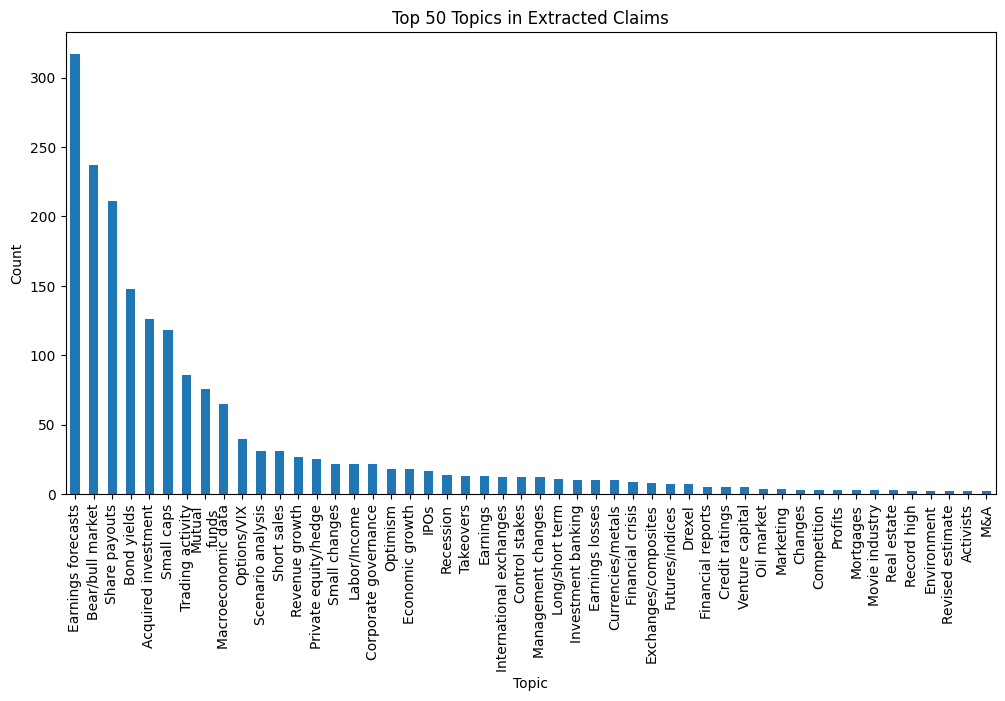

In [46]:
# make histogram of counts of top 30 topics in df_edges
top_topics = df_edges['topic'].value_counts().head(50)
plt.figure(figsize=(12, 6))
top_topics.plot(kind='bar')
plt.title('Top 50 Topics in Extracted Claims')
plt.xlabel('Topic')
plt.ylabel('Count')
